# IMPORTANT

# BEFORE BEGIN... UPDATE MANUALLY URBANIZATION AND MASTER NETWORK CSVs

# Input Data, Variables, and Parameters

In [1]:
import _config
import importlib
importlib.reload(_config)
import numpy as np
import os
import pandas as pd
import arcpy

# Import the required ArcGIS API for Python modules
import arcgis
from arcgis.gis import GIS
gis = arcgis.GIS()
from arcgis.geoanalytics import manage_data

from IPython.display import display, Markdown


# Split the filename and extension based on the last dot
base, extension = _config.fnWfSegments.rsplit('.', 1)

# Add '_GeoKeys' suffix to the filename part
new_filename = os.path.basename(f"{base}_GeoKeys_AADTs.{extension}")

strSegments = os.path.join('intermediate', new_filename)
strGeographies = _config.fnFactorGeos
strMasterNetworkWFRC = _config.fnWfTdm

In [2]:
dirWork         = os.getcwd()
dirInput        = os.path.join(dirWork   , r'input'       )
dirIntermediate = os.path.join(dirWork   , r'intermediate')
dirResults      = os.path.join(dirWork   , r'results'     )
dirParams       = os.path.join(dirWork   , r'params'      )

sStationCol     = 'STATION'
sDayCol         = 'DAY'
sDOWCol         = 'DOW'
sMonthCol       = 'MONTH'
sYearCol        = 'YEAR'
sYearGrpCol     = 'YEARGROUP'
sSeasonGrpCol   = 'SEASONGROUP'
sMonthADTCol    = 'MONTHADT'
sMonthDOWADTCol = 'MONTHDOWADT'
sYearADTCol     = 'YEARADT'
sStationGrpCol  = 'STATIONGROUP'
sDOWGrpCol      = 'DOWGROUP'
sDOWFieldName   = 'DOWFLDNM'
sSGFieldName    = 'SGFLDNM'

#for the geography shapefile, what are all the column names for the various factor geographies
#lGeoFieldNames  = ['WDFACGEO','SSNFACGEO','COFACGEO']
lGeoFieldNames  = ['COFACGEO'] # for update only get combined factors

In [3]:
ProcessGDB = "process_factors.gdb"

#name of new data features
fcTAZAreaType         = os.path.join(dirIntermediate, ProcessGDB + "\TAZAreaType"                 )
fcAreaType            = os.path.join(dirIntermediate, ProcessGDB + "\AreaType"                    )
fcAreaTypeSegment     = os.path.join(dirIntermediate, ProcessGDB + "\AreaTypeSegmentIntersect"    )
fcSegmentsWithAADT    = os.path.join(dirIntermediate, ProcessGDB + "\SegmentsWithAADT"            )
fcGeographies         = os.path.join(dirIntermediate, ProcessGDB + "\Geographies"                 )
#changed to being programmatically defined
#fcSegmentsGeographies = os.path.join(dirIntermediate, ProcessGDB + "\SegmentsGeographiesIntersect")

def deleteIfExists(obj):
    if arcpy.Exists(obj): arcpy.Delete_management(obj)

#if processing geodatabase doesn't exist, create it
print("Checking if " + ProcessGDB + " exists...")
if not arcpy.Exists(os.path.join(dirIntermediate, ProcessGDB)):
    print("Creating " + ProcessGDB + "...")
    arcpy.management.CreateFileGDB(dirIntermediate, ProcessGDB)
else:
    print(ProcessGDB + " exists...")

Checking if process_factors.gdb exists...
process_factors.gdb exists...


In [4]:
#read segment files
sdfSegmentsAll      = pd.DataFrame.spatial.from_featureclass(os.path.join(dirWork, strSegments))

#All SegIDs
dfAllSegIDs = sdfSegmentsAll[['SEGID']]

#read factor geographies
sdfGeographies = pd.DataFrame.spatial.from_featureclass(os.path.join(dirWork, strGeographies))

In [5]:
#CHECK FOR DUPLICATE SEGIDs
_df = sdfSegmentsAll.groupby(['SEGID'], as_index=False).agg(COUNT=('SEGID','count'))
_df[_df['COUNT']>1]

,SEGID,COUNT


In [6]:
#read parameter tables
#csv: , parse_dates=['DATEFROM','DATETO']
prmVolumeGroups                           = pd.read_csv(_config.fnVolumeGroups                                                )
prmFacGrpVolClassToVolGrp                 = pd.read_csv(_config.fnFacGrpVolClassToVolGrp                                      )
prmStationGrpToFacGrpFields               = pd.read_csv(_config.fnStationGrpToFacGrpFields                                    )
prmStationGrpToFacGrpFieldsFacGeoOverride = pd.read_csv(_config.fnStationGrpToFacGrpFieldsFacGeoOverride,dtype = {'ROUTE':str})
prmFacATGrpToAreaType                     = pd.read_csv(_config.fnFacATGrpToAreaType                                          )

# filter by groupings we're only going to use in this update: lGeoFieldNames
prmStationGrpToFacGrpFields = prmStationGrpToFacGrpFields[prmStationGrpToFacGrpFields['FACGEOGROUP'].isin(lGeoFieldNames)]
prmStationGrpToFacGrpFieldsFacGeoOverride = prmStationGrpToFacGrpFieldsFacGeoOverride[prmStationGrpToFacGrpFieldsFacGeoOverride['FACGEOGROUP'].isin(lGeoFieldNames)]

In [7]:
# read USTM taz / urbanization / network
sdfTAZ = pd.DataFrame.spatial.from_featureclass(_config.fnTaz)
dfUrbanization = pd.read_csv(_config.fnUrbanizationCsv,low_memory=False)
#dfUSTMMasterNetwork = pd.read_csv(os.path.join(dirInput, r"USTM_v3.0 - 2023-08-17_DRAFT_Data\USTMv3_MasterNet_Snapped_20230817_Link.csv"),low_memory=False)

# read WFRC network
dfWFRCMasterNetwork = pd.read_csv(_config.fnWfTdmCsv,low_memory=False)

In [8]:
#read processed data
dfCCSFactors = pd.read_csv(_config.fnCcsFactors)

In [9]:
# read factor lookup
dfFacFieldLookup = pd.read_csv(os.path.join(_config.fnCCSFactorsGeoAtypeVolLookup))
pd.set_option('display.max_rows', dfFacFieldLookup.shape[0]+1)
display(dfFacFieldLookup)
pd.set_option('display.max_rows', 10)

,Unnamed: 0,FACGEO,FTGROUP,AREATYPE,VOLUMEFROM,VOLUMETO,STATIONGROUP,FACGEOGROUP
0,125,AlpineLoop,Arterial,1,0,1000000,CO0,COFACGEO
1,126,AlpineLoop,Arterial,2,0,1000000,CO0,COFACGEO
2,127,AlpineLoop,Arterial,3,0,1000000,CO0,COFACGEO
3,128,AlpineLoop,Arterial,4,0,1000000,CO0,COFACGEO
4,129,AlpineLoop,Arterial,5,0,1000000,CO0,COFACGEO
5,130,AlpineLoop,Expressway,1,0,1000000,CO0,COFACGEO
6,131,AlpineLoop,Expressway,2,0,1000000,CO0,COFACGEO
7,132,AlpineLoop,Expressway,3,0,1000000,CO0,COFACGEO
8,133,AlpineLoop,Expressway,4,0,1000000,CO0,COFACGEO
9,134,AlpineLoop,Expressway,5,0,1000000,CO0,COFACGEO


# Calculate Segment Functional Type Group

In [10]:
#dfUSTMMasterNetwork_Segs = dfUSTMMasterNetwork[-dfUSTMMasterNetwork['SEGID'].isna()]
#dfUSTMMasterNetwork_Segs = dfUSTMMasterNetwork_Segs[dfUSTMMasterNetwork_Segs['SEGID']!='NO']
#dfUSTMMasterNetwork_Segs = dfUSTMMasterNetwork_Segs[dfUSTMMasterNetwork_Segs['SEGID']!='N0']
#dfUSTMMasterNetwork_Segs = dfUSTMMasterNetwork_Segs[dfUSTMMasterNetwork_Segs['SEGID']!='0']
#dfUSTMMasterNetwork_Segs = dfUSTMMasterNetwork_Segs[dfUSTMMasterNetwork_Segs['SEGID']!='no']
#dfUSTMMasterNetwork_Segs = dfUSTMMasterNetwork_Segs[dfUSTMMasterNetwork_Segs['SEGID']!='false']
#dfUSTMMasterNetwork_Segs = dfUSTMMasterNetwork_Segs[dfUSTMMasterNetwork_Segs['FT_2019']<100]
#
#dfUSTMMasterNetwork_Segs_2019 = dfUSTMMasterNetwork_Segs[dfUSTMMasterNetwork_Segs['LN_2023']>0]
#dfUSTMMasterNetwork_Segs_2019 = dfUSTMMasterNetwork_Segs_2019.groupby(['SEGID'],as_index=False).agg(MAXFT19_USTM=('FT_2019','max'))
#display(dfUSTMMasterNetwork_Segs_2019)
#dfUSTMMasterNetwork_Segs_2050 = dfUSTMMasterNetwork_Segs[dfUSTMMasterNetwork_Segs['LN23_50']>0]
#dfUSTMMasterNetwork_Segs_2050 = dfUSTMMasterNetwork_Segs_2050.groupby(['SEGID'],as_index=False).agg(MAXFT50_USTM=('FT23_50','max'))
#display(dfUSTMMasterNetwork_Segs_2050)
#

In [11]:
dfWFRCMasterNetwork_Segs = dfWFRCMasterNetwork[['SEGID','LN_2019','LN23_50','FT_2019','FT23_50']]
dfWFRCMasterNetwork_Segs = dfWFRCMasterNetwork_Segs[-dfWFRCMasterNetwork['SEGID'].isna()]
dfWFRCMasterNetwork_Segs = dfWFRCMasterNetwork_Segs[dfWFRCMasterNetwork_Segs['SEGID']!='']
dfWFRCMasterNetwork_Segs = dfWFRCMasterNetwork_Segs[dfWFRCMasterNetwork_Segs['SEGID']!='0']
dfWFRCMasterNetwork_Segs = dfWFRCMasterNetwork_Segs[dfWFRCMasterNetwork_Segs['SEGID']!='false']
dfWFRCMasterNetwork_Segs = dfWFRCMasterNetwork_Segs[dfWFRCMasterNetwork_Segs['FT_2019']<100]

dfWFRCMasterNetwork_Segs_2019 = dfWFRCMasterNetwork_Segs[['SEGID','LN_2019','FT_2019']]

# filter out transit links that have corresponding road seg ids:
dfWFRCMasterNetwork_Segs_2019 = dfWFRCMasterNetwork_Segs_2019[~((~dfWFRCMasterNetwork_Segs_2019['SEGID'].str.startswith('UTA')) & (dfWFRCMasterNetwork_Segs_2019['FT_2019']>50))]
dfWFRCMasterNetwork_Segs_2019 = dfWFRCMasterNetwork_Segs_2019.groupby(['SEGID'],as_index=False).agg(MAXFT19_WFRC=('FT_2019','max'))
display(dfWFRCMasterNetwork_Segs_2019)

dfWFRCMasterNetwork_Segs_2050 = dfWFRCMasterNetwork_Segs[['SEGID','LN23_50','FT23_50']]
dfWFRCMasterNetwork_Segs_2050 = dfWFRCMasterNetwork_Segs_2050[~((~dfWFRCMasterNetwork_Segs_2050['SEGID'].str.startswith('UTA')) & (dfWFRCMasterNetwork_Segs_2050['FT23_50']>50))]
dfWFRCMasterNetwork_Segs_2050 = dfWFRCMasterNetwork_Segs_2050.groupby(['SEGID'],as_index=False).agg(MAXFT50_WFRC=('FT23_50','max'))
display(dfWFRCMasterNetwork_Segs_2050)


,SEGID,MAXFT19_WFRC
0,0006_141.0,2
1,0006_146.9,2
2,0006_149.9,2
3,0006_150.6,2
4,0006_152.6,3
...,...,...
5385,WFRC_8488,5
5386,WFRC_8489,5
5387,WFRC_8490,5
5388,WFRC_8491,5


,SEGID,MAXFT50_WFRC
0,0006_141.0,2
1,0006_146.9,2
2,0006_149.9,2
3,0006_150.6,2
4,0006_152.6,3
...,...,...
5385,WFRC_8488,5
5386,WFRC_8489,5
5387,WFRC_8490,5
5388,WFRC_8491,5


In [12]:
#dfAllSegIDs_FT1 = pd.DataFrame.merge(dfAllSegIDs    ,dfUSTMMasterNetwork_Segs_2019,on='SEGID',how='left')
#dfAllSegIDs_FT2 = pd.DataFrame.merge(dfAllSegIDs_FT1,dfUSTMMasterNetwork_Segs_2050,on='SEGID',how='left')
#dfAllSegIDs_FT3 = pd.DataFrame.merge(dfAllSegIDs_FT2,dfWFRCMasterNetwork_Segs_2019,on='SEGID',how='left')
#dfAllSegIDs_FT4 = pd.DataFrame.merge(dfAllSegIDs_FT3,dfWFRCMasterNetwork_Segs_2050,on='SEGID',how='left')

dfAllSegIDs_FT4 = pd.DataFrame.merge(dfWFRCMasterNetwork_Segs_2019,dfWFRCMasterNetwork_Segs_2050,on='SEGID',how='left')

dfAllSegIDs_FT4 = dfAllSegIDs_FT4.fillna(0)

# fill in this priority until non-zero value found, 19-USTM, 19-WFRC, 50-USTM, 50-WFRC

dfAllSegIDs_FT4['FT'] = 0

#dfAllSegIDs_FT4.loc[((dfAllSegIDs_FT4['FT']==0) & (dfAllSegIDs_FT4['MAXFT19_USTM']>0)),'FT'] = dfAllSegIDs_FT4['MAXFT19_USTM']
dfAllSegIDs_FT4.loc[((dfAllSegIDs_FT4['FT']==0) & (dfAllSegIDs_FT4['MAXFT19_WFRC']>0)),'FT'] = dfAllSegIDs_FT4['MAXFT19_WFRC']
#dfAllSegIDs_FT4.loc[((dfAllSegIDs_FT4['FT']==0) & (dfAllSegIDs_FT4['MAXFT50_USTM']>0)),'FT'] = dfAllSegIDs_FT4['MAXFT50_USTM']
dfAllSegIDs_FT4.loc[((dfAllSegIDs_FT4['FT']==0) & (dfAllSegIDs_FT4['MAXFT50_WFRC']>0)),'FT'] = dfAllSegIDs_FT4['MAXFT50_WFRC']

display(dfAllSegIDs_FT4)

dfSegFT = dfAllSegIDs_FT4[['SEGID','FT']]
dfSegFT

,SEGID,MAXFT19_WFRC,MAXFT50_WFRC,FT
0,0006_141.0,2,2,2
1,0006_146.9,2,2,2
2,0006_149.9,2,2,2
3,0006_150.6,2,2,2
4,0006_152.6,3,3,3
...,...,...,...,...
5385,WFRC_8488,5,5,5
5386,WFRC_8489,5,5,5
5387,WFRC_8490,5,5,5
5388,WFRC_8491,5,5,5


,SEGID,FT
0,0006_141.0,2
1,0006_146.9,2
2,0006_149.9,2
3,0006_150.6,2
4,0006_152.6,3
...,...,...
5385,WFRC_8488,5
5386,WFRC_8489,5
5387,WFRC_8490,5
5388,WFRC_8491,5


In [13]:
dFTGroup = {
     'FTFROM' : [         1,          10,       20,       50],
     'FTTO'   : [         9,          19,       49,      100],
     'FTGROUP': ['Arterial','Expressway','Freeway','Transit']
}
dfFTGroup = pd.DataFrame(dFTGroup)
display(dfFTGroup)

dfSegFTGroup = pd.DataFrame.merge(dfSegFT,dfFTGroup,how='cross')
display(dfSegFTGroup)

dfSegFTGroup = dfSegFTGroup[(dfSegFTGroup['FT']>=dfSegFTGroup['FTFROM']) & (dfSegFTGroup['FT']<=dfSegFTGroup['FTTO'])]
#dfSegFTGroup[dfSegFTGroup['FT']==35]
dfSegFTGroup

,FTFROM,FTTO,FTGROUP
0,1,9,Arterial
1,10,19,Expressway
2,20,49,Freeway
3,50,100,Transit


,SEGID,FT,FTFROM,FTTO,FTGROUP
0,0006_141.0,2,1,9,Arterial
1,0006_141.0,2,10,19,Expressway
2,0006_141.0,2,20,49,Freeway
3,0006_141.0,2,50,100,Transit
4,0006_146.9,2,1,9,Arterial
...,...,...,...,...,...
21555,WFRC_8491,5,50,100,Transit
21556,WFRC_8492,4,1,9,Arterial
21557,WFRC_8492,4,10,19,Expressway
21558,WFRC_8492,4,20,49,Freeway


,SEGID,FT,FTFROM,FTTO,FTGROUP
0,0006_141.0,2,1,9,Arterial
4,0006_146.9,2,1,9,Arterial
8,0006_149.9,2,1,9,Arterial
12,0006_150.6,2,1,9,Arterial
16,0006_152.6,3,1,9,Arterial
...,...,...,...,...,...
21540,WFRC_8488,5,1,9,Arterial
21544,WFRC_8489,5,1,9,Arterial
21548,WFRC_8490,5,1,9,Arterial
21552,WFRC_8491,5,1,9,Arterial


In [14]:
#join to all segids and segments without a match set FTGroup to Arterial
dfAllSegFTGroup = pd.DataFrame.merge(dfAllSegIDs,dfSegFTGroup[['SEGID','FTGROUP']],on='SEGID',how='left')
display("Check NULLs:")
display(dfAllSegFTGroup[dfAllSegFTGroup.isnull().any(axis=1)])

#set to Arterial for all segs not in WF/USTM model
dfAllSegFTGroup = dfAllSegFTGroup.fillna('Arterial')
display(dfAllSegFTGroup)

#summarize record count
dfAllSegFTGroup_Count = dfAllSegFTGroup.groupby(['FTGROUP'],as_index=False).agg(COUNT=('SEGID','size'))
display(dfAllSegFTGroup_Count)

'Check NULLs:'

,SEGID,FTGROUP
35,0006_221.1,NaN
1012,0168_000.0,NaN
1158,0190_015.7,NaN
1160,0190_016.1,NaN
1261,0209_000.4,NaN
...,...,...
4564,MAG_6500,NaN
5046,WFRC_8028,NaN
5047,WFRC_8030,NaN
5056,WFRC_8045,NaN


,SEGID,FTGROUP
0,0006_141.0,Arterial
1,0006_146.9,Arterial
2,0006_149.9,Arterial
3,0006_150.6,Arterial
4,0006_152.6,Arterial
...,...,...
5475,WFRC_8489,Arterial
5476,WFRC_8490,Arterial
5477,WFRC_8491,Arterial
5478,WFRC_8492,Arterial


,FTGROUP,COUNT
0,Arterial,4985
1,Expressway,82
2,Freeway,324
3,Transit,89


# Calculate Area Type for Segments

In [15]:
sdfTAZWithUrbanization = pd.DataFrame.merge(sdfTAZ,dfUrbanization,left_on='TAZID',right_on='Z',how='left')
sdfTAZWithUrbanization = sdfTAZWithUrbanization[['TAZID','ATYPE','SHAPE']]

In [16]:
##create map1 with zoom set to Salt Lake (any city or place name can be used)
#map1 = gis.map('Salt Lake')
#
#
##expression to classify enrollment
#
#arcexp_ccs = ("var v = $feature.AREATYPE;        "
#              "if      (v==1) { return 'one'   ;}"
#              "else if (v==2) { return 'two'   ;}"
#              "else if (v==3) { return 'three' ;}"
#              "else if (v==4) { return 'four'  ;}"
#              "else if (v==5) { return 'five'  ;}"
#              "else           { return 'other' ;}")
#
##symbology for enrollment classes
#unival_ccs = [
#                {"value":"one"   , "label":"1-Rural"     , "symbol":{"type":"esriSFS","color":[135,206,235,168],"size": "18px","outline":{"color":[255,255,255],"width":0}}},
#                {"value":"two"   , "label":"2-Transition", "symbol":{"type":"esriSFS","color":[  0,255,  0,168],"size": "18px","outline":{"color":[255,255,255],"width":0}}},
#                {"value":"three" , "label":"3-Subrban"   , "symbol":{"type":"esriSFS","color":[255,255,  0,168],"size": "18px","outline":{"color":[255,255,255],"width":0}}},
#                {"value":"four"  , "label":"4-Urban"     , "symbol":{"type":"esriSFS","color":[247,148, 29,168],"size": "18px","outline":{"color":[255,255,255],"width":0}}},
#                {"value":"five"  , "label":"5-CBD"       , "symbol":{"type":"esriSFS","color":[255,  0,  0,168],"size": "18px","outline":{"color":[255,255,255],"width":0}}},
#                {"value":"six"   , "label":"None"        , "symbol":{"type":"esriSFS","color":[  0,  0,  0,168],"size": "18px","outline":{"color":[255,255,255],"width":0}}}
#             ]
#
##define sdf layer
#sdfTAZWithUrbanization.spatial.plot(map_widget = map1,
#                                    renderer_type     = 'u-a',
#                                    unique_values     = unival_ccs,
#                                    arcade_expression = arcexp_ccs,
#                                    default_symbol    = ""
#                                   )
#
#map1.layout.height='600px'
#map1.legend=True
#
##add map title
#display(Markdown('<h2><center>TAZ Area Type</center></h2>'))
#
##display the map
#map1

In [17]:
#export TAZ Area Type to intermediate gdb
deleteIfExists(fcTAZAreaType)
deleteIfExists(fcAreaType)
sdfTAZWithUrbanization.spatial.to_featureclass(location=fcTAZAreaType, sanitize_columns=False)
arcpy.management.Dissolve(fcTAZAreaType, fcAreaType, ['ATYPE'])
print('All Done')

All Done


In [18]:
sdfSegmentsAll

,FID,SEGID,BMP,EMP,DISTANCE,CO_FIPS,ROUTE,SUBAREAID,PLANAREA,DIRECTION,...,SUTRK2013,CUTRK2013,SUTRK2012,CUTRK2012,SUTRK2011,CUTRK2011,SUTRK2010,CUTRK2010,Shape__Len,SHAPE
0,0,0006_141.0,141.035,146.868,5.843301,49.0,0006,1.0,MAG,EB/WB,...,0.069628124,0.060300209,0.078625,0.066644806,0.076659734,0.063559876,0.090717089,0.052861231,14331.237256,"{""paths"": [[[405824.11000000034, 4423860.33], ..."
1,1,0006_146.9,146.868,149.902,3.039023,49.0,0006,1.0,MAG,EB/WB,...,0.069628124,0.060300209,0.078625,0.066644806,0.076659734,0.063559876,0.090717089,0.052861231,14331.237256,"{""paths"": [[[413442.55030000024, 4422753.7282]..."
2,2,0006_149.9,149.902,150.580,0.677983,49.0,0006,1.0,MAG,EB/WB,...,0.111862613,0.092806024,0.116361,0.095978323,0.115378418,0.094435858,0.122407096,0.089086536,4266.379040,"{""paths"": [[[418330.7999999998, 4422866], [418..."
3,3,0006_150.6,150.580,152.555,1.973104,49.0,0006,1.0,MAG,EB/WB,...,0.111862613,0.092806024,0.116361,0.095978323,0.115378418,0.094435858,0.122407096,0.089086536,4266.379040,"{""paths"": [[[419421.8803000003, 4422872.2963],..."
4,4,0006_152.6,152.555,152.871,0.316275,49.0,0006,1.0,MAG,EB/WB,...,0.154097102,0.12531184,0.154097,0.12531184,0.154097102,0.12531184,0.154097102,0.12531184,505.334907,"{""paths"": [[[422596.89969999995, 4422889.2949]..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5475,5475,WFRC_8489,0.000,0.000,0.505514,35.0,WFRC,1.0,WFRC,EB/WB,...,0,0,0.000000,0,0,0,0,0,0.000000,"{""paths"": [[[420577.9068, 4495035.7042], [4205..."
5476,5476,WFRC_8490,0.000,0.000,0.737896,35.0,WFRC,1.0,WFRC,EB/WB,...,0,0,0.000000,0,0,0,0,0,0.000000,"{""paths"": [[[421385.5, 4495026.199999999], [42..."
5477,5477,WFRC_8491,0.000,0.000,0.265495,35.0,WFRC,1.0,WFRC,EB/WB,...,0,0,0.000000,0,0,0,0,0,0.000000,"{""paths"": [[[422563.71669999976, 4495144.5842]..."
5478,5478,WFRC_8492,0.000,0.000,0.444725,35.0,WFRC,1.0,WFRC,NB/SB,...,0,0,0.000000,0,0,0,0,0,0.000000,"{""paths"": [[[423341.02249999996, 4513066.2261]..."


In [19]:
#export segments to intermediate gdb

sdfSegments_2019AADT = sdfSegmentsAll[['SEGID','AADT2019','SHAPE']].copy()

deleteIfExists(fcSegmentsWithAADT)
sdfSegments_2019AADT.spatial.to_featureclass(location=fcSegmentsWithAADT, sanitize_columns=False)
arcpy.AddField_management(fcSegmentsWithAADT, "SEGLENGTH" , "DOUBLE")
arcpy.CalculateField_management(fcSegmentsWithAADT,
                                "SegLength",
                                "!shape.length@miles!",
                                "PYTHON_9.3")
print('All Done')

All Done


In [20]:
deleteIfExists(fcAreaTypeSegment)
arcpy.analysis.Intersect([fcSegmentsWithAADT,fcAreaType],fcAreaTypeSegment)


# Execute DeleteField
arcpy.AddField_management(fcAreaTypeSegment, "PIECELENGTH" , "DOUBLE")
arcpy.CalculateField_management(fcAreaTypeSegment,
                                "PIECELENGTH",
                                "!shape.length@miles!",
                                "PYTHON_9.3")


<Result 'd:\\GitHub\\WF-TDM-v9x\\1_Inputs\\6_Segment\\_Segment Processing Tools\\intermediate\\process_factors.gdb\\AreaTypeSegmentIntersect'>

In [21]:
sdfSegmentsAreaType = pd.DataFrame.spatial.from_featureclass(fcAreaTypeSegment)


In [22]:
#create map1 with zoom set to Salt Lake (any city or place name can be used)
#map2 = gis.map('Salt Lake')
#
##expression to classify enrollment
#
#arcexp_ccs = ("var v = $feature.AREATYPE;        "
#              "if      (v==1) { return 'one'   ;}"
#              "else if (v==2) { return 'two'   ;}"
#              "else if (v==3) { return 'three' ;}"
#              "else if (v==4) { return 'four'  ;}"
#              "else if (v==5) { return 'five'  ;}"
#              "else           { return 'other' ;}")
#
##symbology for enrollment classes
#unival_ccs = [
#                {"value":"one"   , "label":"1-Rural"     , "symbol":{"type":"esriSLS","color":[135,206,235,168],"width": 2}},
#                {"value":"two"   , "label":"2-Transition", "symbol":{"type":"esriSLS","color":[  0,255,  0,168],"width": 2}},
#                {"value":"three" , "label":"3-Subrban"   , "symbol":{"type":"esriSLS","color":[255,255,  0,168],"width": 2}},
#                {"value":"four"  , "label":"4-Urban"     , "symbol":{"type":"esriSLS","color":[247,148, 29,168],"width": 2}},
#                {"value":"five"  , "label":"5-CBD"       , "symbol":{"type":"esriSLS","color":[255,  0,  0,168],"width": 2}},
#                {"value":"six"   , "label":"None"        , "symbol":{"type":"esriSLS","color":[  0,  0,  0,168],"width": 2}}
#             ]
#
##define sdf layer
#sdfSegmentsAreaType.spatial.plot(map_widget = map2,
#                                 renderer_type     = 'u-a',
#                                 unique_values     = unival_ccs,
#                                 arcade_expression = arcexp_ccs,
#                                 default_symbol    = ""
#                                )
#
#map2.layout.height='600px'
#map2.legend=True
#
##add map title
#display(Markdown('<h2><center>Segment Piece Area Type</center></h2>'))
#
##display the map
#map2

In [23]:
dfSegmentsAreaType_MaxLength = sdfSegmentsAreaType.groupby('SEGID',as_index=False).agg(MAXPIECELEN=('PIECELENGTH','max'))
dfSegmentsAreaType_MaxLength

,SEGID,MAXPIECELEN
0,0006_141.0,5.843301
1,0006_146.9,3.039023
2,0006_149.9,0.677983
3,0006_150.6,1.973104
4,0006_152.6,0.316275
...,...,...
5474,WFRC_8489,0.505514
5475,WFRC_8490,0.737896
5476,WFRC_8491,0.264876
5477,WFRC_8492,0.236235


In [24]:
dfSegmentsAT = pd.DataFrame.merge(sdfSegmentsAreaType,dfSegmentsAreaType_MaxLength,left_on=('SEGID','PIECELENGTH'),right_on=('SEGID','MAXPIECELEN'))

#get max just incase segment equally divided between two area types
dfSegmentsAT = dfSegmentsAT.groupby(['SEGID'],as_index=False).agg(ATYPE=('ATYPE','max'))

dfSegmentsAT = dfSegmentsAT[['SEGID','ATYPE']]
dfSegmentsAT

,SEGID,ATYPE
0,0006_141.0,1.0
1,0006_146.9,1.0
2,0006_149.9,1.0
3,0006_150.6,1.0
4,0006_152.6,1.0
...,...,...
5474,WFRC_8489,3.0
5475,WFRC_8490,3.0
5476,WFRC_8491,3.0
5477,WFRC_8492,4.0


In [25]:
dfSegmentsAT[dfSegmentsAT['SEGID']=='Dixie_5134']

,SEGID,ATYPE


In [26]:
#find missing SEGID
dfSegsInTAZintersect = dfSegmentsAreaType_MaxLength
dfAllSegIDs_dfSegsInTAZintersect = pd.DataFrame.merge(dfAllSegIDs,dfSegsInTAZintersect,on='SEGID',how="outer")
dfAllSegIDs_dfSegsInTAZintersect[dfAllSegIDs_dfSegsInTAZintersect.isnull().any(axis=1)]

,SEGID,MAXPIECELEN
4094,MAG_6000,NaN


In [27]:
## MAG_6000 is in Juab County
# ## need to manually set Area Type
#
dfSegmentsAT.loc[len(dfSegmentsAT.index)] = ['MAG_6000',1]
dfSegmentsAT

#this is not true for this data

,SEGID,ATYPE
0,0006_141.0,1.0
1,0006_146.9,1.0
2,0006_149.9,1.0
3,0006_150.6,1.0
4,0006_152.6,1.0
...,...,...
5475,WFRC_8490,3.0
5476,WFRC_8491,3.0
5477,WFRC_8492,4.0
5478,WFRC_8493,3.0


In [28]:
sdfSegmentsWithAADT    = pd.DataFrame.spatial.from_featureclass(fcSegmentsWithAADT)
sdfSegmentsWithAADT_AT = pd.DataFrame.merge(sdfSegmentsWithAADT,dfSegmentsAT,on='SEGID')

len(sdfSegmentsWithAADT_AT.index)
display(sdfSegmentsWithAADT_AT)

,OBJECTID,SEGID,AADT2019,SEGLENGTH,SHAPE,ATYPE
0,1,0006_141.0,1517.0,5.843301,"{'paths': [[[405824.11000000034, 4423860.33], ...",1.0
1,2,0006_146.9,1517.0,3.039023,"{'paths': [[[413442.55030000024, 4422753.7282]...",1.0
2,3,0006_149.9,2441.0,0.677983,"{'paths': [[[418330.7999999998, 4422866], [418...",1.0
3,4,0006_150.6,2441.0,1.973104,"{'paths': [[[419421.8803000003, 4422872.2963],...",1.0
4,5,0006_152.6,2417.0,0.316275,"{'paths': [[[422596.89969999995, 4422889.2949]...",1.0
...,...,...,...,...,...,...
5475,5476,WFRC_8489,0.0,0.505514,"{'paths': [[[420577.9068, 4495035.7042], [4205...",3.0
5476,5477,WFRC_8490,0.0,0.737896,"{'paths': [[[421385.5, 4495026.199999999], [42...",3.0
5477,5478,WFRC_8491,0.0,0.265495,"{'paths': [[[422563.71669999976, 4495144.5842]...",3.0
5478,5479,WFRC_8492,0.0,0.444725,"{'paths': [[[423341.02249999996, 4513066.2261]...",4.0


In [29]:
##create map1 with zoom set to Salt Lake (any city or place name can be used)
#map3 = gis.map('Salt Lake')
#
#arcexp_ccs = ("var v = $feature.AREATYPE;        "
#              "if      (v==1) { return 'one'   ;}"
#              "else if (v==2) { return 'two'   ;}"
#              "else if (v==3) { return 'three' ;}"
#              "else if (v==4) { return 'four'  ;}"
#              "else if (v==5) { return 'five'  ;}"
#              "else           { return 'other' ;}")
#
##symbology for enrollment classes
#unival_ccs = [
#                {"value":"one"   , "label":"1-Rural"     , "symbol":{"type":"esriSLS","color":[135,206,235,168],"width": 2}},
#                {"value":"two"   , "label":"2-Transition", "symbol":{"type":"esriSLS","color":[  0,255,  0,168],"width": 3}},
#                {"value":"three" , "label":"3-Subrban"   , "symbol":{"type":"esriSLS","color":[255,255,  0,168],"width": 4}},
#                {"value":"four"  , "label":"4-Urban"     , "symbol":{"type":"esriSLS","color":[247,148, 29,168],"width": 5}},
#                {"value":"five"  , "label":"5-CBD"       , "symbol":{"type":"esriSLS","color":[255,  0,  0,168],"width": 6}},
#                {"value":"six"   , "label":"None"        , "symbol":{"type":"esriSLS","color":[  0,  0,  0,168],"width": 2}}
#             ]
#
##define sdf layer
#sdfSegmentsWithAADT_AT.spatial.plot(map_widget = map3,
#                                    renderer_type     = 'u-a',
#                                    unique_values     = unival_ccs,
#                                    arcade_expression = arcexp_ccs,
#                                    default_symbol    = ""
#                                   )
#
#map3.layout.height='600px'
#map3.legend=True
#
##add map title
#display(Markdown('<h2><center>Segment Area Type</center></h2>'))
#
##display the map
#map3

In [30]:
#add area type overrides

#read csv
prmAreaTypeOverridesSeg   = pd.read_csv(_config.fnATOverride)

#show any duplicates
display("PLEASE REMOVE THESE DUPLICATES FROM " + _config.fnATOverride + ":")
dupes = prmAreaTypeOverridesSeg['SEGID'].duplicated()
display(prmAreaTypeOverridesSeg['SEGID'][dupes])

sdfSegmentsWithAADT_AT_wOverride = pd.DataFrame.merge(sdfSegmentsWithAADT_AT,prmAreaTypeOverridesSeg,on='SEGID',how='left')

sdfSegmentsWithAADT_AT_wOverride['ATOVERRIDE'].fillna(0,inplace=True)
sdfSegmentsWithAADT_AT_wOverride['NOTE'].fillna("",inplace=True)

sdfSegmentsWithAADT_AT_wOverride['ATYPE'] = sdfSegmentsWithAADT_AT_wOverride['ATYPE'].astype(int)
sdfSegmentsWithAADT_AT_wOverride['ATOVERRIDE'] = sdfSegmentsWithAADT_AT_wOverride['ATOVERRIDE'].astype(int)
#display(sdfSegmentsWithAADT_AT_wOverride)

#update Area Type for records that have Area Type Override value
sdfSegmentsWithAADT_AT_wOverride.loc[(sdfSegmentsWithAADT_AT_wOverride['ATOVERRIDE']>0),'ATYPE'] = sdfSegmentsWithAADT_AT_wOverride['ATOVERRIDE']
#display(sdfSegmentsWithAADT_AT_wOverride)

#change override column to flag
sdfSegmentsWithAADT_AT_wOverride.loc[(sdfSegmentsWithAADT_AT_wOverride['ATOVERRIDE']>0),'ATOVERRIDE'] = 1
len(sdfSegmentsWithAADT_AT_wOverride.index)

'PLEASE REMOVE THESE DUPLICATES FROM data/Factors/params/area_type_overrides_segments.csv:'

Series([], Name: SEGID, dtype: object)

5480

In [31]:
# CHRIS TO CHECK VISUALLY THAT THESE OVERRIDES WORK
sdfSegmentsWithAADT_AT_wOverride[sdfSegmentsWithAADT_AT_wOverride['ATOVERRIDE']==1]

,OBJECTID,SEGID,AADT2019,SEGLENGTH,SHAPE,ATYPE,ATOVERRIDE,NOTE
46,47,0015_241.6,28510.0,0.860278,"{'paths': [[[430737.0700000003, 4421371.93], [...",1,1,south of Santaquin make rural
48,49,0015_244.8,44054.0,2.111597,"{'paths': [[[434064.75, 4425332.869999999], [4...",2,1,Santaquin to SF Main St make transition
49,50,0015_246.9,44054.0,1.921154,"{'paths': [[[434919.21999999974, 4428554.88000...",2,1,Santaquin to SF Main St make transition
50,51,0015_248.8,48398.0,2.085966,"{'paths': [[[435422.20999999996, 4431521.02], ...",2,1,Santaquin to SF Main St make transition
51,52,0015_250.9,62573.0,0.793074,"{'paths': [[[437525.86000000034, 4434135.08], ...",2,1,Santaquin to SF Main St make transition
...,...,...,...,...,...,...,...,...
83,84,0015_286.8,183972.0,1.386834,"{'paths': [[[422704.9269000003, 4479930.849099...",3,1,At Point-of-the Mountain make at least suburban
91,92,0015_297.9,275014.0,1.090042,"{'paths': [[[423544.4400000004, 4497051.84], [...",4,1,through SL Valley make urban
108,109,0015_311.4,136120.0,0.484349,"{'paths': [[[422066.6500000004, 4518048.039999...",3,1,between SL and Davis counties make at least su...
109,110,0015_311.8,168352.0,1.321821,"{'paths': [[[422386.6699999999, 4518734.84], [...",3,1,between SL and Davis counties make at least su...


In [32]:
##create map1 with zoom set to Salt Lake (any city or place name can be used)
#map4 = gis.map('Salt Lake')
#map4.basemap = 'gray-vector'
#
##expression to classify enrollment
#
#arcexp_ccs = ("var at = $feature.AREATYPE;                      "
#              "var ov = $feature.ATOVERRIDE;                    "
#              "if      (at==1 && ov==0) { return 'one_orig'  ;} "
#              "else if (at==2 && ov==0) { return 'two_orig'  ;} "
#              "else if (at==3 && ov==0) { return 'three_orig';} "
#              "else if (at==4 && ov==0) { return 'four_orig' ;} "
#              "else if (at==5 && ov==0) { return 'five_orig' ;} "
#              "else if (at==1 && ov==1) { return 'one_ov'    ;} "
#              "else if (at==2 && ov==1) { return 'two_ov'    ;} "
#              "else if (at==3 && ov==1) { return 'three_ov'  ;} "
#              "else if (at==4 && ov==1) { return 'four_ov'   ;} "
#              "else if (at==5 && ov==1) { return 'five_ov'   ;} "
#              "else                     { return 'other'     ;} ")
#
##symbology for enrollment classes
#unival_ccs = [
#                {"value":"one_orig"  , "label":"1-Rural"              , "symbol":{"type":"esriSLS","color":[135,206,235, 80],"width": 1.5}},
#                {"value":"two_orig"  , "label":"2-Transition"         , "symbol":{"type":"esriSLS","color":[  0,255,  0, 80],"width": 2.0}},
#                {"value":"three_orig", "label":"3-Subrban"            , "symbol":{"type":"esriSLS","color":[255,255,  0, 80],"width": 2.5}},
#                {"value":"four_orig" , "label":"4-Urban"              , "symbol":{"type":"esriSLS","color":[247,148, 29, 80],"width": 3.0}},
#                {"value":"five_orig" , "label":"5-CBD"                , "symbol":{"type":"esriSLS","color":[255,  0,  0, 80],"width": 3.5}},
#                {"value":"one_ov"    , "label":"1-Rural Override"     , "symbol":{"type":"esriSLS","color":[135,206,235,255],"width": 2.0}},
#                {"value":"two_ov"    , "label":"2-Transition Override", "symbol":{"type":"esriSLS","color":[  0,255,  0,255],"width": 3.5}},
#                {"value":"three_ov"  , "label":"3-Subrban Override"   , "symbol":{"type":"esriSLS","color":[255,255,  0,255],"width": 4.0}},
#                {"value":"four_ov"   , "label":"4-Urban Override"     , "symbol":{"type":"esriSLS","color":[247,148, 29,255],"width": 4.5}},
#                {"value":"five_ov"   , "label":"5-CBD Override"       , "symbol":{"type":"esriSLS","color":[255,  0,  0,255],"width": 5.0}},
#                {"value":"other"     , "label":"None"                 , "symbol":{"type":"esriSLS","color":[  0,  0,  0,168],"width": 1.0}}
#             ]
#
##define sdf layer
#sdfSegmentsWithAADT_AT_wOverride.spatial.plot(map_widget = map4,
#                                              renderer_type     = 'u-a',
#                                              unique_values     = unival_ccs,
#                                              arcade_expression = arcexp_ccs,
#                                              default_symbol    = ""
#                                             )
#
#map4.layout.height='600px'
#map4.legend=True
#
##add map title
#display(Markdown('<h2><center>Segment Area Type with Overrides</center></h2>'))
#
##display the map
#map4

In [33]:
dfSegIDVolAT = sdfSegmentsWithAADT_AT_wOverride[['SEGID','AADT2019','ATYPE']]
dfSegIDVolAT

,SEGID,AADT2019,ATYPE
0,0006_141.0,1517.0,1
1,0006_146.9,1517.0,1
2,0006_149.9,2441.0,1
3,0006_150.6,2441.0,1
4,0006_152.6,2417.0,1
...,...,...,...
5475,WFRC_8489,0.0,3
5476,WFRC_8490,0.0,3
5477,WFRC_8491,0.0,3
5478,WFRC_8492,0.0,4


# Get Factor Geographies

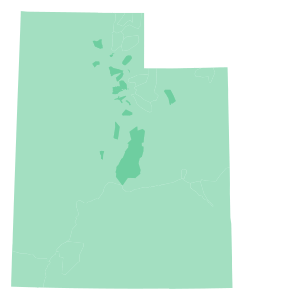

Index(['FID', 'SSNFACGEO', 'COFACGEO', 'WDFACGEO', 'SHAPE'], dtype='object')

In [34]:
display(sdfGeographies.spatial)
sdfGeographies.columns

In [35]:
##create map1 with zoom set to Salt Lake (any city or place name can be used)
#map5 = gis.map('Salt Lake')
#
##define sdf layer
#sdfGeographies.spatial.plot(map_widget=map5,renderer_type='u',col='COFACGEO',default_symbol="",cmap='nipy_spectral',alpha=0.7)
#
#map5.layout.height='700px'
#map5.legend=True
#
##add map title
#display(Markdown('<h2><center>Combined Group Geographies</center></h2>'))
#
##display the map
#map5

In [36]:
#export to geodatabase in order to use arcpy join features, etc
sdfGeographies.spatial.to_featureclass(location=fcGeographies, sanitize_columns=False)

'd:\\GitHub\\WF-TDM-v9x\\1_Inputs\\6_Segment\\_Segment Processing Tools\\intermediate\\process_factors.gdb\\Geographies'

In [37]:
#create segment definition for each geography...
#need to dissolve for factor group that may share different shape in geography feature class

dfSegmentsGeo_Combined = pd.DataFrame(columns = ['SEGID','FACGEOGROUP','FACGEO'])


for sGeoFieldName in lGeoFieldNames:
    display("Obtaining geographies from field: " + sGeoFieldName)
    fcGeographiesDissolve = os.path.join(dirIntermediate, ProcessGDB + "\GeographiesDissolve_" + sGeoFieldName)    
    fcSegmentsGeographies = os.path.join(dirIntermediate, ProcessGDB + "\SegmentsGeographiesIntersect_" + sGeoFieldName)
    
    deleteIfExists(fcGeographiesDissolve)
    arcpy.management.Dissolve(fcGeographies, fcGeographiesDissolve, sGeoFieldName)
    
    deleteIfExists(fcSegmentsGeographies)
    arcpy.analysis.Intersect([fcSegmentsWithAADT,fcGeographiesDissolve],fcSegmentsGeographies)

    # Execute DeleteField
    arcpy.AddField_management(fcSegmentsGeographies, "PIECELENGTH" , "DOUBLE")
    arcpy.CalculateField_management(fcSegmentsGeographies,
                                    "PIECELENGTH",
                                    "!shape.length@miles!",
                                    "PYTHON_9.3")
    
    sdfSegmentsGeographies = pd.DataFrame.spatial.from_featureclass(fcSegmentsGeographies)
    dfSegmentsGeographies_MaxLength = sdfSegmentsGeographies.groupby('SEGID',as_index=False).agg(MAXPIECELEN=('PIECELENGTH','max'))
    display(dfSegmentsGeographies_MaxLength)
    
    dfSegmentsGeo = pd.DataFrame.merge(sdfSegmentsGeographies,dfSegmentsGeographies_MaxLength,left_on=('SEGID','PIECELENGTH'),right_on=('SEGID','MAXPIECELEN'))
    dfSegmentsGeo = dfSegmentsGeo[['SEGID',sGeoFieldName]]
    dfSegmentsGeo.columns = ('SEGID','FACGEO')
    dfSegmentsGeo['FACGEOGROUP'] = sGeoFieldName
    
    dfSegmentsGeo_Combined = dfSegmentsGeo_Combined.append(dfSegmentsGeo, ignore_index=True)

    display(dfSegmentsGeo)

display(dfSegmentsGeo_Combined)

'Obtaining geographies from field: COFACGEO'

,SEGID,MAXPIECELEN
0,0006_141.0,5.843301
1,0006_146.9,3.039023
2,0006_149.9,0.677983
3,0006_150.6,1.973104
4,0006_152.6,0.316275
...,...,...
5475,WFRC_8489,0.505514
5476,WFRC_8490,0.737896
5477,WFRC_8491,0.265495
5478,WFRC_8492,0.444725


C:\Users\cday\AppData\Local\Temp\ipykernel_36980\1278590701.py:34: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  dfSegmentsGeo_Combined = dfSegmentsGeo_Combined.append(dfSegmentsGeo, ignore_index=True)


,SEGID,FACGEO,FACGEOGROUP
0,0006_141.0,Statewide,COFACGEO
1,0006_146.9,Statewide,COFACGEO
2,0006_149.9,Statewide,COFACGEO
3,0006_150.6,Statewide,COFACGEO
4,0006_152.6,Statewide,COFACGEO
...,...,...,...
5475,WFRC_8490,Statewide,COFACGEO
5476,WFRC_8491,Statewide,COFACGEO
5477,WFRC_8492,Statewide,COFACGEO
5478,WFRC_8493,Statewide,COFACGEO


,SEGID,FACGEOGROUP,FACGEO
0,0006_141.0,COFACGEO,Statewide
1,0006_146.9,COFACGEO,Statewide
2,0006_149.9,COFACGEO,Statewide
3,0006_150.6,COFACGEO,Statewide
4,0006_152.6,COFACGEO,Statewide
...,...,...,...
5475,WFRC_8490,COFACGEO,Statewide
5476,WFRC_8491,COFACGEO,Statewide
5477,WFRC_8492,COFACGEO,Statewide
5478,WFRC_8493,COFACGEO,Statewide


In [38]:
# Check if each segment has the right number of FACGEOs

dfSegmentsGeo_Combined_count = dfSegmentsGeo_Combined.groupby(['SEGID'],as_index=False).agg(NUMREC=('FACGEO','size'))
dfSegmentsGeo_Combined_missinggeo = dfSegmentsGeo_Combined_count[dfSegmentsGeo_Combined_count['NUMREC']!=len(lGeoFieldNames)]
display("SEGMENTS WITH MISSING GEOS... CORRECT BEFORE PROCEECING:")
display(dfSegmentsGeo_Combined_missinggeo)

'SEGMENTS WITH MISSING GEOS... CORRECT BEFORE PROCEECING:'

,SEGID,NUMREC


In [39]:
#change list to dataframe
dfGeoFieldNames = pd.DataFrame(lGeoFieldNames,columns=['FACGEOGROUP'])

#cross join, creating records for each geo field name
sdfSegmentsAADT_AT_FacGeo = pd.DataFrame.merge(sdfSegmentsWithAADT_AT_wOverride,dfGeoFieldNames,how='cross')                                            
                                               
sdfSegAADTATGeo = pd.DataFrame.merge(sdfSegmentsAADT_AT_FacGeo,dfSegmentsGeo_Combined,on=('SEGID','FACGEOGROUP'),how='outer')
sdfSegAADTATGeoFTGroup = pd.DataFrame.merge(sdfSegAADTATGeo,dfAllSegFTGroup,on='SEGID')
sdfSegAADTATGeoFTGroup['ROUTE'] =  sdfSegAADTATGeoFTGroup['SEGID'].str.split('_').str[0] #get all before first underscore
sdfSegAADTATGeoFTGroup['MP'   ] =  sdfSegAADTATGeoFTGroup['SEGID'].str.split('_').str[1].astype(float) #get all after first underscore
sdfSegAADTATGeoFTGroup

,OBJECTID,SEGID,AADT2019,SEGLENGTH,SHAPE,ATYPE,ATOVERRIDE,NOTE,FACGEOGROUP,FACGEO,FTGROUP,ROUTE,MP
0,1,0006_141.0,1517.0,5.843301,"{'paths': [[[405824.11000000034, 4423860.33], ...",1,0,,COFACGEO,Statewide,Arterial,0006,141.0
1,2,0006_146.9,1517.0,3.039023,"{'paths': [[[413442.55030000024, 4422753.7282]...",1,0,,COFACGEO,Statewide,Arterial,0006,146.9
2,3,0006_149.9,2441.0,0.677983,"{'paths': [[[418330.7999999998, 4422866], [418...",1,0,,COFACGEO,Statewide,Arterial,0006,149.9
3,4,0006_150.6,2441.0,1.973104,"{'paths': [[[419421.8803000003, 4422872.2963],...",1,0,,COFACGEO,Statewide,Arterial,0006,150.6
4,5,0006_152.6,2417.0,0.316275,"{'paths': [[[422596.89969999995, 4422889.2949]...",1,0,,COFACGEO,Statewide,Arterial,0006,152.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5475,5476,WFRC_8489,0.0,0.505514,"{'paths': [[[420577.9068, 4495035.7042], [4205...",3,0,,COFACGEO,Statewide,Arterial,WFRC,8489.0
5476,5477,WFRC_8490,0.0,0.737896,"{'paths': [[[421385.5, 4495026.199999999], [42...",3,0,,COFACGEO,Statewide,Arterial,WFRC,8490.0
5477,5478,WFRC_8491,0.0,0.265495,"{'paths': [[[422563.71669999976, 4495144.5842]...",3,0,,COFACGEO,Statewide,Arterial,WFRC,8491.0
5478,5479,WFRC_8492,0.0,0.444725,"{'paths': [[[423341.02249999996, 4513066.2261]...",4,0,,COFACGEO,Statewide,Arterial,WFRC,8492.0


In [40]:
# update FACGEO for non-geography shapefile defined segments (e.g. many freeways)
sdfFacGeoOverride = pd.DataFrame.merge(sdfSegAADTATGeoFTGroup,prmStationGrpToFacGrpFieldsFacGeoOverride,on=('ROUTE','FACGEOGROUP'))
sdfFacGeoOverride = sdfFacGeoOverride[((sdfFacGeoOverride['MP']>=sdfFacGeoOverride['MPFROM']) & (sdfFacGeoOverride['MP']<=sdfFacGeoOverride['MPTO']))]

dfFacGeoOverride = sdfFacGeoOverride[['SEGID','FACGEOGROUP','FACGEO_NEW']]
#display(dfFacGeoOverride)

sdfSegAADTATGeoFTGroup_wOverrides = pd.DataFrame.merge(sdfSegAADTATGeoFTGroup,dfFacGeoOverride,on=('SEGID','FACGEOGROUP'),how='left')
sdfSegAADTATGeoFTGroup_wOverrides.loc[~(sdfSegAADTATGeoFTGroup_wOverrides['FACGEO_NEW'].isna()),'FACGEO'] = sdfSegAADTATGeoFTGroup_wOverrides['FACGEO_NEW']
display(sdfSegAADTATGeoFTGroup_wOverrides[~sdfSegAADTATGeoFTGroup_wOverrides['FACGEO_NEW'].isna()])
sdfSegAADTATGeoFTGroup_wOverrides = sdfSegAADTATGeoFTGroup_wOverrides[['SEGID','AADT2019','ATYPE','FACGEOGROUP','FACGEO','FTGROUP','SHAPE']]
display(sdfSegAADTATGeoFTGroup_wOverrides)

,OBJECTID,SEGID,AADT2019,SEGLENGTH,SHAPE,ATYPE,ATOVERRIDE,NOTE,FACGEOGROUP,FACGEO,FTGROUP,ROUTE,MP,FACGEO_NEW
46,47,0015_241.6,28510.0,0.860278,"{'paths': [[[430737.0700000003, 4421371.93], [...",1,1,south of Santaquin make rural,COFACGEO,I15,Freeway,0015,241.6,I15
47,48,0015_242.4,31333.0,2.383252,"{'paths': [[[431436.86950000003, 4422562.27030...",2,0,,COFACGEO,I15,Freeway,0015,242.4,I15
48,49,0015_244.8,44054.0,2.111597,"{'paths': [[[434064.75, 4425332.869999999], [4...",2,1,Santaquin to SF Main St make transition,COFACGEO,I15,Freeway,0015,244.8,I15
49,50,0015_246.9,44054.0,1.921154,"{'paths': [[[434919.21999999974, 4428554.88000...",2,1,Santaquin to SF Main St make transition,COFACGEO,I15,Freeway,0015,246.9,I15
50,51,0015_248.8,48398.0,2.085966,"{'paths': [[[435422.20999999996, 4431521.02], ...",2,1,Santaquin to SF Main St make transition,COFACGEO,I15,Freeway,0015,248.8,I15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1321,1322,0215_022.3,94563.0,1.340705,"{'paths': [[[419787.6699999999, 4513150.42], [...",4,0,,COFACGEO,I215,Freeway,0215,22.3,I215
1322,1323,0215_023.7,80227.0,1.956919,"{'paths': [[[419930.61000000034, 4515296.15], ...",3,0,,COFACGEO,I215,Freeway,0215,23.7,I215
1323,1324,0215_025.7,75533.0,1.024613,"{'paths': [[[419955.53000000026, 4518444.97000...",2,0,,COFACGEO,I215,Freeway,0215,25.7,I215
1324,1325,0215_026.7,42492.0,0.772272,"{'paths': [[[420140.51999999955, 4520067.77999...",3,0,,COFACGEO,I215,Freeway,0215,26.7,I215


,SEGID,AADT2019,ATYPE,FACGEOGROUP,FACGEO,FTGROUP,SHAPE
0,0006_141.0,1517.0,1,COFACGEO,Statewide,Arterial,"{'paths': [[[405824.11000000034, 4423860.33], ..."
1,0006_146.9,1517.0,1,COFACGEO,Statewide,Arterial,"{'paths': [[[413442.55030000024, 4422753.7282]..."
2,0006_149.9,2441.0,1,COFACGEO,Statewide,Arterial,"{'paths': [[[418330.7999999998, 4422866], [418..."
3,0006_150.6,2441.0,1,COFACGEO,Statewide,Arterial,"{'paths': [[[419421.8803000003, 4422872.2963],..."
4,0006_152.6,2417.0,1,COFACGEO,Statewide,Arterial,"{'paths': [[[422596.89969999995, 4422889.2949]..."
...,...,...,...,...,...,...,...
5475,WFRC_8489,0.0,3,COFACGEO,Statewide,Arterial,"{'paths': [[[420577.9068, 4495035.7042], [4205..."
5476,WFRC_8490,0.0,3,COFACGEO,Statewide,Arterial,"{'paths': [[[421385.5, 4495026.199999999], [42..."
5477,WFRC_8491,0.0,3,COFACGEO,Statewide,Arterial,"{'paths': [[[422563.71669999976, 4495144.5842]..."
5478,WFRC_8492,0.0,4,COFACGEO,Statewide,Arterial,"{'paths': [[[423341.02249999996, 4513066.2261]..."


In [41]:
#check if amy duplication of segments occurred
dfCount = sdfSegAADTATGeoFTGroup_wOverrides.groupby(['SEGID','FACGEOGROUP'],as_index=False).agg(COUNT=('AADT2019','size'))
dfCount = dfCount[dfCount['COUNT']>1]
dfCount

,SEGID,FACGEOGROUP,COUNT


In [42]:
dfFacFieldLookup

,Unnamed: 0,FACGEO,FTGROUP,AREATYPE,VOLUMEFROM,VOLUMETO,STATIONGROUP,FACGEOGROUP
0,125,AlpineLoop,Arterial,1,0,1000000,CO0,COFACGEO
1,126,AlpineLoop,Arterial,2,0,1000000,CO0,COFACGEO
2,127,AlpineLoop,Arterial,3,0,1000000,CO0,COFACGEO
3,128,AlpineLoop,Arterial,4,0,1000000,CO0,COFACGEO
4,129,AlpineLoop,Arterial,5,0,1000000,CO0,COFACGEO
...,...,...,...,...,...,...,...,...
209,50,Washington,Freeway,1,0,1000000,COX,COFACGEO
210,51,Washington,Freeway,2,0,1000000,COX,COFACGEO
211,52,Washington,Freeway,3,0,1000000,COX,COFACGEO
212,53,Washington,Freeway,4,0,1000000,COX,COFACGEO


In [43]:
#FT Overrides
dfFTGroupOverride = pd.read_csv(_config.fnFTGroupOverride)
display(dfFTGroupOverride)

sdfSegFacMatch_FTOverride = pd.DataFrame.merge(sdfSegAADTATGeoFTGroup_wOverrides,dfFTGroupOverride,on='SEGID',how='left')

#override FTGROUP
sdfSegFacMatch_FTOverride.loc[~(sdfSegFacMatch_FTOverride['FTGROUP_NEW'].isna()),'FTGROUP'] = sdfSegFacMatch_FTOverride['FTGROUP_NEW']

#change to FTGROUP_NEW to flag
sdfSegFacMatch_FTOverride.loc[~(sdfSegFacMatch_FTOverride['FTGROUP_NEW'].isna()),'FTGROUP_NEW'] = 1

#show overriden records
display(sdfSegFacMatch_FTOverride[sdfSegFacMatch_FTOverride['FTGROUP_NEW']==1])

dfFacFieldLookup.rename(columns={'AREATYPE':'ATYPE'}, inplace=True)

sdfSegFacMatch = pd.DataFrame.merge(sdfSegFacMatch_FTOverride,dfFacFieldLookup,on=('FACGEOGROUP','FACGEO','FTGROUP','ATYPE'),how='left')

sdfSegFacMatchFacGroup = sdfSegFacMatch[((sdfSegFacMatch['AADT2019']>=sdfSegFacMatch['VOLUMEFROM']) & (sdfSegFacMatch['AADT2019']<sdfSegFacMatch['VOLUMETO']))]
#show rows with matching records
#display(sdfSegFacMatchFacGroup)

sdfSegFacMatch2 = pd.DataFrame.merge(sdfSegFacMatch_FTOverride,sdfSegFacMatchFacGroup,on=('SEGID','FACGEOGROUP','FACGEO','FTGROUP','ATYPE','AADT2019','SHAPE'),how='left')
display("unmatched:")
display(sdfSegFacMatch2[sdfSegFacMatch2['STATIONGROUP'].isna()])

sdfSegFacMatch2 = sdfSegFacMatch2[['SEGID','AADT2019','ATYPE','FACGEOGROUP','FACGEO','FTGROUP','STATIONGROUP','SHAPE']]
sdfSegFacMatch2['STATIONGROUP'] = sdfSegFacMatch2['STATIONGROUP'].fillna('')
display("final table:")

# MANUALLY SET TRANSIST
sdfSegFacMatch2.loc[sdfSegFacMatch2['FTGROUP']=='Transit', 'STATIONGROUP'] = 'TRN'

display(sdfSegFacMatch2)




,SEGID,FTGROUP_NEW,NOTE
0,0040_008.2,Freeway,US40 just north of Heber
1,0080_155.0,Freeway,no links in TDM
2,Dixie_5134,Arterial,new road piece just over AZ border
3,0067_004.0,Freeway,need to fix SEGID in TDM
4,0201_000.0,Freeway,treat 201 the same as freeway portion for factors
...,...,...,...
46,0080_128.7,Freeway,Expanded WFRC model area didn't have SEGIDs de...
47,0080_130.4,Freeway,Expanded WFRC model area didn't have SEGIDs de...
48,0080_131.9,Freeway,Expanded WFRC model area didn't have SEGIDs de...
49,0080_133.7,Freeway,Expanded WFRC model area didn't have SEGIDs de...


,SEGID,AADT2019,ATYPE,FACGEOGROUP,FACGEO,FTGROUP,SHAPE,FTGROUP_NEW,NOTE
215,0052_003.7,36980.0,4,COFACGEO,Statewide,Arterial,"{'paths': [[[443500.4400000004, 4462596.390000...",1,treat flyovers at Provo Canyon mouth as arterial
230,0067_004.0,0.0,2,COFACGEO,Legacy,Freeway,"{'paths': [[[421643.61010000017, 4526294.94009...",1,need to fix SEGID in TDM
446,0080_128.7,58852.0,1,COFACGEO,I80SR186US40,Freeway,"{'paths': [[[433362, 4507122.73], [433392.7999...",1,Expanded WFRC model area didn't have SEGIDs de...
447,0080_130.4,58978.0,1,COFACGEO,I80SR186US40,Freeway,"{'paths': [[[435390.33999999985, 4508894.27999...",1,Expanded WFRC model area didn't have SEGIDs de...
448,0080_131.9,57805.0,1,COFACGEO,I80SR186US40,Freeway,"{'paths': [[[437290.1299999999, 4510096.800000...",1,Expanded WFRC model area didn't have SEGIDs de...
...,...,...,...,...,...,...,...,...,...
4305,MAG_6233,0.0,1,COFACGEO,Statewide,Freeway,"{'paths': [[[410931.2423999999, 4460562.436100...",1,Utah Lake Crossings
4310,MAG_6239,0.0,2,COFACGEO,Statewide,Freeway,"{'paths': [[[426287.4000000004, 4457858.58], [...",1,Utah Lake Crossings
4311,MAG_6240,0.0,2,COFACGEO,Statewide,Freeway,"{'paths': [[[426287.4000000004, 4457858.58], [...",1,Utah Lake Crossings
4313,MAG_6242,0.0,2,COFACGEO,Statewide,Freeway,"{'paths': [[[426287.4000000004, 4457858.58], [...",1,Utah Lake Crossings


'unmatched:'

,SEGID,AADT2019,ATYPE,FACGEOGROUP,FACGEO,FTGROUP,SHAPE,FTGROUP_NEW_x,NOTE_x,FTGROUP_NEW_y,NOTE_y,Unnamed: 0,VOLUMEFROM,VOLUMETO,STATIONGROUP
4938,UTA_7110,0.0,4,COFACGEO,Statewide,Transit,"{'paths': [[[423340, 4512836], [423823, 451281...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4939,UTA_7120,0.0,4,COFACGEO,Statewide,Transit,"{'paths': [[[424300.06549999956, 4511846.10339...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4940,UTA_7121,0.0,4,COFACGEO,Statewide,Transit,"{'paths': [[[424300.06549999956, 4511846.10339...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4941,UTA_7122,0.0,4,COFACGEO,Statewide,Transit,"{'paths': [[[424300.06549999956, 4511846.10339...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4942,UTA_7126,0.0,4,COFACGEO,Statewide,Transit,"{'paths': [[[424295.9232000001, 4511366.6711],...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5022,UTA_9576,0.0,3,COFACGEO,Statewide,Transit,"{'paths': [[[438326.5963000003, 4459103.093800...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5023,UTA_9580,0.0,3,COFACGEO,Statewide,Transit,"{'paths': [[[445692.733, 4445756.658399999], [...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5024,UTA_9584,0.0,3,COFACGEO,Statewide,Transit,"{'paths': [[[442158.45150000043, 4440093.24929...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5025,UTA_9588,0.0,1,COFACGEO,Statewide,Transit,"{'paths': [[[438286.2599999998, 4435273.4759],...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


'final table:'

,SEGID,AADT2019,ATYPE,FACGEOGROUP,FACGEO,FTGROUP,STATIONGROUP,SHAPE
0,0006_141.0,1517.0,1,COFACGEO,Statewide,Arterial,COP,"{'paths': [[[405824.11000000034, 4423860.33], ..."
1,0006_146.9,1517.0,1,COFACGEO,Statewide,Arterial,COP,"{'paths': [[[413442.55030000024, 4422753.7282]..."
2,0006_149.9,2441.0,1,COFACGEO,Statewide,Arterial,COP,"{'paths': [[[418330.7999999998, 4422866], [418..."
3,0006_150.6,2441.0,1,COFACGEO,Statewide,Arterial,COP,"{'paths': [[[419421.8803000003, 4422872.2963],..."
4,0006_152.6,2417.0,1,COFACGEO,Statewide,Arterial,COP,"{'paths': [[[422596.89969999995, 4422889.2949]..."
...,...,...,...,...,...,...,...,...
5475,WFRC_8489,0.0,3,COFACGEO,Statewide,Arterial,COT,"{'paths': [[[420577.9068, 4495035.7042], [4205..."
5476,WFRC_8490,0.0,3,COFACGEO,Statewide,Arterial,COT,"{'paths': [[[421385.5, 4495026.199999999], [42..."
5477,WFRC_8491,0.0,3,COFACGEO,Statewide,Arterial,COT,"{'paths': [[[422563.71669999976, 4495144.5842]..."
5478,WFRC_8492,0.0,4,COFACGEO,Statewide,Arterial,COU,"{'paths': [[[423341.02249999996, 4513066.2261]..."


In [44]:
sdfSegFacMatch2[sdfSegFacMatch2['SEGID'].str.contains('UTA')]

,SEGID,AADT2019,ATYPE,FACGEOGROUP,FACGEO,FTGROUP,STATIONGROUP,SHAPE
4898,UTA_0500,0.0,4,COFACGEO,Statewide,Arterial,COU,"{'paths': [[[420698.50009999983, 4508188.5044]..."
4899,UTA_0987,0.0,2,COFACGEO,Statewide,Arterial,COS,"{'paths': [[[438182.20490000024, 4435268.63319..."
4900,UTA_0988,0.0,2,COFACGEO,Statewide,Arterial,COS,"{'paths': [[[441933.9746000003, 4440277.2599],..."
4901,UTA_0989,0.0,3,COFACGEO,Statewide,Arterial,COT,"{'paths': [[[446144.1068000002, 4445754.374199..."
4902,UTA_0990,0.0,4,COFACGEO,Statewide,Arterial,COU,"{'paths': [[[443771.4667999996, 4452821.994100..."
...,...,...,...,...,...,...,...,...
5022,UTA_9576,0.0,3,COFACGEO,Statewide,Transit,TRN,"{'paths': [[[438326.5963000003, 4459103.093800..."
5023,UTA_9580,0.0,3,COFACGEO,Statewide,Transit,TRN,"{'paths': [[[445692.733, 4445756.658399999], [..."
5024,UTA_9584,0.0,3,COFACGEO,Statewide,Transit,TRN,"{'paths': [[[442158.45150000043, 4440093.24929..."
5025,UTA_9588,0.0,1,COFACGEO,Statewide,Transit,TRN,"{'paths': [[[438286.2599999998, 4435273.4759],..."


In [45]:
sdfSegFacMatch2_duplicates = sdfSegFacMatch2.groupby(['SEGID','AADT2019','ATYPE'],as_index=False).agg(COUNT=('FACGEOGROUP','size'))
sdfSegFacMatch2_duplicates[sdfSegFacMatch2_duplicates['COUNT']!=len(lGeoFieldNames)]

,SEGID,AADT2019,ATYPE,COUNT


In [46]:
sdfSegFacMatch2_tocsv = sdfSegFacMatch2[['SEGID','AADT2019','ATYPE','FTGROUP','FACGEO','STATIONGROUP']]
sdfSegFacMatch2_tocsv.to_csv(os.path.join(dirIntermediate, 'SegmentsMatchedToFactorGroups.csv'),index=False)

In [47]:
sdfSegFacMatch2_pivot = sdfSegFacMatch2.pivot(index=('SEGID','AADT2019','ATYPE','SHAPE'), columns='FACGEOGROUP', values='STATIONGROUP')
sdfSegFacMatch2_pivot = sdfSegFacMatch2_pivot.reset_index()
sdfSegFacMatch2_pivot

FACGEOGROUP,SEGID,AADT2019,ATYPE,SHAPE,COFACGEO
0,0006_141.0,1517.0,1,"{'paths': [[[405824.11000000034, 4423860.33], ...",COP
1,0006_146.9,1517.0,1,"{'paths': [[[413442.55030000024, 4422753.7282]...",COP
2,0006_149.9,2441.0,1,"{'paths': [[[418330.7999999998, 4422866], [418...",COP
3,0006_150.6,2441.0,1,"{'paths': [[[419421.8803000003, 4422872.2963],...",COP
4,0006_152.6,2417.0,1,"{'paths': [[[422596.89969999995, 4422889.2949]...",COP
...,...,...,...,...,...
5475,WFRC_8489,0.0,3,"{'paths': [[[420577.9068, 4495035.7042], [4205...",COT
5476,WFRC_8490,0.0,3,"{'paths': [[[421385.5, 4495026.199999999], [42...",COT
5477,WFRC_8491,0.0,3,"{'paths': [[[422563.71669999976, 4495144.5842]...",COT
5478,WFRC_8492,0.0,4,"{'paths': [[[423341.02249999996, 4513066.2261]...",COU


In [48]:
# Split the filename and extension based on the last dot
base, extension = _config.fnWfSegments.rsplit('.', 1)

# Add '_GeoKeys' suffix to the filename part
new_filename = os.path.basename(f"{base}_FacGeos.{extension}")

sdfSegFacMatch2_pivot.spatial.to_featureclass(location=os.path.join('intermediate/' + new_filename), sanitize_columns=False)
print('Exported: intermediate/' + new_filename)
print("Done!")


Exported: intermediate/WFv910_Segments_FacGeos.shp
Done!


In [49]:
#create map1 with zoom set to Salt Lake (any city or place name can be used)
map8 = gis.map('Salt Lake')

#define sdf layer
sdfSegFacMatch2_pivot.spatial.plot(map_widget=map8,renderer_type='u',col='COFACGEO',default_symbol="",cmap='nipy_spectral',alpha=0.7)

map8.layout.height='700px'
map8.legend=True

#add map title
display(Markdown('<h2><center>Segments by Group Geographies</center></h2>'))

#display the map
map8

<h2><center>Segments by Group Geographies</center></h2>

MapView(layout=Layout(height='700px', width='100%'), legend=True)

In [50]:
#intermediate output
dfFactors = pd.read_csv(_config.fnCcsFactors)
dfSegFac  = pd.read_csv(os.path.join(dirIntermediate, 'SegmentsMatchedToFactorGroups.csv'))
#dfSegFacWithTrk = pd.read_csv(os.path.join(dirIntermediate, r'SegmentTruckFactors.csv'))

#Start with UDOT Base
#sdfSegments = pd.DataFrame.spatial.from_featureclass(os.path.join(dirWork,  r"arcgis\UDOT-Segments.gdb\Master_Segs_20210811"))

#Start with Modified Base - and strip down of factor fields
sdfSegments = pd.DataFrame.spatial.from_featureclass(os.path.join(dirWork, strSegments))
#sdfSegments = sdfSegments.drop(columns=['FAC_MON'  ,'FAC_TUE'  ,'FAC_WED'  ,'FAC_THU'  ,'FAC_FRI'  ,'FAC_SAT'  ,'FAC_SUN'  ,'FAC_WDAVG','FAC_WEAVG','FAC_WEMAX','FAC_JAN'  ,'FAC_FEB'  ,'FAC_MAR'  ,'FAC_APR'  ,'FAC_MAY'  ,'FAC_JUN'  ,'FAC_JUL'  ,'FAC_AUG'  ,'FAC_SEP'  ,'FAC_OCT'  ,'FAC_NOV'  ,'FAC_DEC'  ,'FAC_WIN'   ,'FAC_SPR'   ,'FAC_SUM'   ,'FAC_FAL'  ,'FAC_MAXMO','FAC_MAX'  ,'FACMANADJ','CUTRUCKS','SUTRUCKS'])

#sdfSegments = sdfSegments[['SEGID','BMP','EMP','DISTANCE','PLANAREA','AADT2019','SUBAREAID','CO_FIPS','SHAPE']]

In [51]:
#parameters
prmInterpolate = pd.read_csv(_config.fnInterpolate)

In [52]:

dfFactorGroupsToPublish = pd.DataFrame(_config.dFactorGroupsToPublish)
display(dfFactorGroupsToPublish)

dfStationGroupsToPublish = pd.DataFrame(_config.dStationGroupsToPublish)
display(dfStationGroupsToPublish)

dfToPublish = pd.DataFrame.merge(dfStationGroupsToPublish,dfFactorGroupsToPublish,how='cross')

dfFactorsToPublish = pd.DataFrame.merge(dfFactors,dfToPublish,on=('STATIONGROUP','SEASONGROUP','YEARGROUP','FACTORNAME'))
dfFactorsToPublish = dfFactorsToPublish[['STATIONGROUP','FACTORNAME','FACTOR']]
display(dfFactorsToPublish)



,SEASONGROUP,YEARGROUP,FACTORNAME
0,Year,2015-2019,FAC_MON
1,Year,2015-2019,FAC_TUE
2,Year,2015-2019,FAC_WED
3,Year,2015-2019,FAC_THU
4,Year,2015-2019,FAC_FRI
...,...,...,...
23,S02-Spring,2015-2019,FAC_SPR
24,S03-Summer,2015-2019,FAC_SUM
25,S04-Fall,2015-2019,FAC_FAL
26,Year,2015-2019,FAC_MAXMO


,STATIONGROUP
0,CO0
1,CO1
2,CO2
3,CO3
4,CO7
...,...
32,COU
33,XX3
34,COV
35,COW


,STATIONGROUP,FACTORNAME,FACTOR
0,CO0,FAC_JAN,0.320612
1,CO1,FAC_JAN,0.432402
2,CO2,FAC_JAN,1.140254
3,CO3,FAC_JAN,0.385754
4,CO4,FAC_JAN,0.751806
...,...,...,...
1031,XX3,FAC_TUE,1.146486
1032,XX3,FAC_WDAVG,1.156760
1033,XX3,FAC_WEAVG,0.631137
1034,XX3,FAC_WED,1.158740


In [53]:
#pivot for final table
dfFactorsToPublishStationGroup_pivot = dfFactorsToPublish.pivot(index=('STATIONGROUP'),columns='FACTORNAME',values='FACTOR')

dfFactorsToPublishStationGroup_pivot = dfFactorsToPublishStationGroup_pivot.reset_index()

# Add a row with zeros

# Create a new row
new_row = {'STATIONGROUP': 'TRN'}
for col in dfFactorsToPublishStationGroup_pivot.columns:
    if col != 'STATIONGROUP':
        new_row[col] = 0

# Append the new row to the dataframe
dfFactorsToPublishStationGroup_pivot = dfFactorsToPublishStationGroup_pivot.append(new_row, ignore_index=True)

# reverse pivot for long table:
dfFactorsToPublish = dfFactorsToPublishStationGroup_pivot.melt(id_vars=('STATIONGROUP'), var_name="FACTORNAME", value_name="FACTOR")

dfFactorsToPublishStationGroup_pivot.to_csv(os.path.join(dirResults, r'CCSFactors.csv'),index=False)
#display(dfFactorsToPublishStationGroup_pivot)


C:\Users\cday\AppData\Local\Temp\ipykernel_36980\797250551.py:15: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  dfFactorsToPublishStationGroup_pivot = dfFactorsToPublishStationGroup_pivot.append(new_row, ignore_index=True)


In [54]:
dfSegFacToPublish = pd.DataFrame.merge(dfSegFac,dfFactorsToPublish,on='STATIONGROUP',how="left")
display(dfSegFacToPublish[dfSegFacToPublish['SEGID'].str.contains('UTA')])
display(dfSegFacToPublish)

,SEGID,AADT2019,ATYPE,FTGROUP,FACGEO,STATIONGROUP,FACTORNAME,FACTOR
137144,UTA_0500,0.0,4,Arterial,Statewide,COU,FAC_APR,1.014230
137145,UTA_0500,0.0,4,Arterial,Statewide,COU,FAC_AUG,1.022302
137146,UTA_0500,0.0,4,Arterial,Statewide,COU,FAC_DEC,0.990750
137147,UTA_0500,0.0,4,Arterial,Statewide,COU,FAC_FAL,1.009500
137148,UTA_0500,0.0,4,Arterial,Statewide,COU,FAC_FEB,0.970454
...,...,...,...,...,...,...,...,...
140751,UTA_9592,0.0,3,Transit,Statewide,TRN,FAC_WDAVG,0.000000
140752,UTA_9592,0.0,3,Transit,Statewide,TRN,FAC_WEAVG,0.000000
140753,UTA_9592,0.0,3,Transit,Statewide,TRN,FAC_WED,0.000000
140754,UTA_9592,0.0,3,Transit,Statewide,TRN,FAC_WEMAX,0.000000


,SEGID,AADT2019,ATYPE,FTGROUP,FACGEO,STATIONGROUP,FACTORNAME,FACTOR
0,0006_141.0,1517.0,1,Arterial,Statewide,COP,FAC_APR,1.036642
1,0006_141.0,1517.0,1,Arterial,Statewide,COP,FAC_AUG,1.089736
2,0006_141.0,1517.0,1,Arterial,Statewide,COP,FAC_DEC,0.882206
3,0006_141.0,1517.0,1,Arterial,Statewide,COP,FAC_FAL,1.031575
4,0006_141.0,1517.0,1,Arterial,Statewide,COP,FAC_FEB,0.850375
...,...,...,...,...,...,...,...,...
153435,WFRC_8493,0.0,3,Arterial,Statewide,COT,FAC_WDAVG,1.092362
153436,WFRC_8493,0.0,3,Arterial,Statewide,COT,FAC_WEAVG,0.765260
153437,WFRC_8493,0.0,3,Arterial,Statewide,COT,FAC_WED,1.088655
153438,WFRC_8493,0.0,3,Arterial,Statewide,COT,FAC_WEMAX,0.924463


In [55]:
#manual interpolatation

display(prmInterpolate)

dfFactorsToPublish_InterpolateFrom = pd.DataFrame.merge(prmInterpolate,dfSegFacToPublish,left_on='SEGIDFROM',right_on='SEGID')
dfFactorsToPublish_InterpolateFrom = dfFactorsToPublish_InterpolateFrom[['SEGIDTOREV','FACTORNAME','FACTOR','PORTIONFROM']]
dfFactorsToPublish_InterpolateFrom = dfFactorsToPublish_InterpolateFrom.rename(columns={'FACTOR':'FACTORFROM'})
display(dfFactorsToPublish_InterpolateFrom)

dfFactorsToPublish_InterpolateTo   = pd.DataFrame.merge(prmInterpolate,dfSegFacToPublish,left_on='SEGIDTO'  ,right_on='SEGID')
dfFactorsToPublish_InterpolateTo   = dfFactorsToPublish_InterpolateTo  [['SEGIDTOREV','FACTORNAME','FACTOR','PORTIONTO']]
dfFactorsToPublish_InterpolateTo   = dfFactorsToPublish_InterpolateTo.rename(columns={'FACTOR':'FACTORTO'})
display(dfFactorsToPublish_InterpolateTo)

dfFactorsToPublish_Interpolate = pd.DataFrame.merge(dfFactorsToPublish_InterpolateFrom,dfFactorsToPublish_InterpolateTo,on=('SEGIDTOREV','FACTORNAME'))

dfFactorsToPublish_Interpolate['PF'] = dfFactorsToPublish_Interpolate['PORTIONFROM']/(dfFactorsToPublish_Interpolate['PORTIONTO']+dfFactorsToPublish_Interpolate['PORTIONFROM'])
dfFactorsToPublish_Interpolate['PT'] = dfFactorsToPublish_Interpolate['PORTIONTO'  ]/(dfFactorsToPublish_Interpolate['PORTIONTO']+dfFactorsToPublish_Interpolate['PORTIONFROM'])
dfFactorsToPublish_Interpolate['FACTORINTERPOLATED'] = dfFactorsToPublish_Interpolate['FACTORFROM'] * dfFactorsToPublish_Interpolate['PF'] + dfFactorsToPublish_Interpolate['FACTORTO'] * dfFactorsToPublish_Interpolate['PT']
display(dfFactorsToPublish_Interpolate)

dfFactorsToPublish_Interpolate = dfFactorsToPublish_Interpolate[['SEGIDTOREV','FACTORNAME','FACTORINTERPOLATED']]
dfFactorsToPublish_Interpolate = dfFactorsToPublish_Interpolate.rename(columns={'SEGIDTOREV':'SEGID'})
dfFactorsToPublish_Interpolate

,ID,SEGIDTOREV,SEGIDFROM,PORTIONFROM,SEGIDTO,PORTIONTO
0,1,0015_225.3,0015_222.8,11,0015_261.8,1
1,2,0015_225.8,0015_222.8,11,0015_261.8,1
2,3,0015_228.1,0015_222.8,10,0015_261.8,2
3,4,0015_230.0,0015_222.8,10,0015_261.8,2
4,5,0015_233.0,0015_222.8,10,0015_261.8,2
...,...,...,...,...,...,...
64,65,0006_175.6,0006_178.8,5,0006_173.4,6
65,66,0006_174.9,0006_178.8,4,0006_173.4,7
66,67,0006_174.4,0006_178.8,3,0006_173.4,8
67,68,0006_174.0,0006_178.8,2,0006_173.4,9


,SEGIDTOREV,FACTORNAME,FACTORFROM,PORTIONFROM
0,0015_349.4,FAC_APR,1.006596,9
1,0015_349.4,FAC_AUG,1.101546,9
2,0015_349.4,FAC_DEC,0.934678,9
3,0015_349.4,FAC_FAL,1.013803,9
4,0015_349.4,FAC_FEB,0.871004,9
...,...,...,...,...
835,0006_173.7,FAC_WDAVG,0.959262,1
836,0006_173.7,FAC_WEAVG,1.014440,1
837,0006_173.7,FAC_WED,0.952876,1
838,0006_173.7,FAC_WEMAX,1.107057,1


,SEGIDTOREV,FACTORNAME,FACTORTO,PORTIONTO
0,0015_225.3,FAC_APR,1.018984,1
1,0015_225.3,FAC_AUG,1.039075,1
2,0015_225.3,FAC_DEC,0.989176,1
3,0015_225.3,FAC_FAL,1.013135,1
4,0015_225.3,FAC_FEB,0.938123,1
...,...,...,...,...
1367,0006_173.7,FAC_WDAVG,1.156760,10
1368,0006_173.7,FAC_WEAVG,0.631137,10
1369,0006_173.7,FAC_WED,1.158740,10
1370,0006_173.7,FAC_WEMAX,0.733154,10


,SEGIDTOREV,FACTORNAME,FACTORFROM,PORTIONFROM,FACTORTO,PORTIONTO,PF,PT,FACTORINTERPOLATED
0,0080_124.1,FAC_APR,0.979742,5,0.879025,1,0.833333,0.166667,0.962956
1,0080_124.1,FAC_AUG,1.056728,5,1.154115,1,0.833333,0.166667,1.072959
2,0080_124.1,FAC_DEC,0.975044,5,0.945462,1,0.833333,0.166667,0.970114
3,0080_124.1,FAC_FAL,1.012474,5,0.979889,1,0.833333,0.166667,1.007044
4,0080_124.1,FAC_FEB,0.957638,5,0.939971,1,0.833333,0.166667,0.954693
...,...,...,...,...,...,...,...,...,...
527,0006_173.7,FAC_WDAVG,0.959262,1,1.156760,10,0.090909,0.909091,1.138806
528,0006_173.7,FAC_WEAVG,1.014440,1,0.631137,10,0.090909,0.909091,0.665982
529,0006_173.7,FAC_WED,0.952876,1,1.158740,10,0.090909,0.909091,1.140025
530,0006_173.7,FAC_WEMAX,1.107057,1,0.733154,10,0.090909,0.909091,0.767145


,SEGID,FACTORNAME,FACTORINTERPOLATED
0,0080_124.1,FAC_APR,0.962956
1,0080_124.1,FAC_AUG,1.072959
2,0080_124.1,FAC_DEC,0.970114
3,0080_124.1,FAC_FAL,1.007044
4,0080_124.1,FAC_FEB,0.954693
...,...,...,...
527,0006_173.7,FAC_WDAVG,1.138806
528,0006_173.7,FAC_WEAVG,0.665982
529,0006_173.7,FAC_WED,1.140025
530,0006_173.7,FAC_WEMAX,0.767145


In [56]:
#update with interpolated values

dfSegFacToPublishWithInterpolation = pd.DataFrame.merge(dfSegFacToPublish,dfFactorsToPublish_Interpolate,on=('SEGID','FACTORNAME'),how='left')
dfSegFacToPublishWithInterpolation = dfSegFacToPublishWithInterpolation.fillna(0)
dfSegFacToPublishWithInterpolation.loc[(dfSegFacToPublishWithInterpolation['FACTORINTERPOLATED']>0),'FACTOR'] = dfSegFacToPublishWithInterpolation['FACTORINTERPOLATED']

dfSegFacToPublishWithInterpolation['FACMANADJ'] = 0
dfSegFacToPublishWithInterpolation.loc[(dfSegFacToPublishWithInterpolation['FACTORINTERPOLATED']>0),'FACMANADJ'] = 1


dfSegFacToPublishWithInterpolation['FACTOR'] = round(dfSegFacToPublishWithInterpolation['FACTOR'],4)

display(dfSegFacToPublishWithInterpolation[dfSegFacToPublishWithInterpolation['FACTORINTERPOLATED']>0])

display(dfSegFacToPublishWithInterpolation)

,SEGID,AADT2019,ATYPE,FTGROUP,FACGEO,STATIONGROUP,FACTORNAME,FACTOR,FACTORINTERPOLATED,FACMANADJ
476,0006_173.7,34688.0,4,Freeway,Statewide,XX3,FAC_APR,1.0104,1.010414,1
477,0006_173.7,34688.0,4,Freeway,Statewide,XX3,FAC_AUG,1.0421,1.042138,1
478,0006_173.7,34688.0,4,Freeway,Statewide,XX3,FAC_DEC,0.9519,0.951947,1
479,0006_173.7,34688.0,4,Freeway,Statewide,XX3,FAC_FAL,1.0098,1.009795,1
480,0006_173.7,34688.0,4,Freeway,Statewide,XX3,FAC_FEB,0.9523,0.952326,1
...,...,...,...,...,...,...,...,...,...,...
145959,WFRC_8218,0.0,3,Freeway,Statewide,XX3,FAC_WDAVG,1.0222,1.022154,1
145960,WFRC_8218,0.0,3,Freeway,Statewide,XX3,FAC_WEAVG,0.9200,0.920031,1
145961,WFRC_8218,0.0,3,Freeway,Statewide,XX3,FAC_WED,1.0228,1.022814,1
145962,WFRC_8218,0.0,3,Freeway,Statewide,XX3,FAC_WEMAX,1.0118,1.011838,1


,SEGID,AADT2019,ATYPE,FTGROUP,FACGEO,STATIONGROUP,FACTORNAME,FACTOR,FACTORINTERPOLATED,FACMANADJ
0,0006_141.0,1517.0,1,Arterial,Statewide,COP,FAC_APR,1.0366,0.0,0
1,0006_141.0,1517.0,1,Arterial,Statewide,COP,FAC_AUG,1.0897,0.0,0
2,0006_141.0,1517.0,1,Arterial,Statewide,COP,FAC_DEC,0.8822,0.0,0
3,0006_141.0,1517.0,1,Arterial,Statewide,COP,FAC_FAL,1.0316,0.0,0
4,0006_141.0,1517.0,1,Arterial,Statewide,COP,FAC_FEB,0.8504,0.0,0
...,...,...,...,...,...,...,...,...,...,...
153435,WFRC_8493,0.0,3,Arterial,Statewide,COT,FAC_WDAVG,1.0924,0.0,0
153436,WFRC_8493,0.0,3,Arterial,Statewide,COT,FAC_WEAVG,0.7653,0.0,0
153437,WFRC_8493,0.0,3,Arterial,Statewide,COT,FAC_WED,1.0887,0.0,0
153438,WFRC_8493,0.0,3,Arterial,Statewide,COT,FAC_WEMAX,0.9245,0.0,0


In [57]:
#pivot for final table

dfFactorsToPublish_pivot = dfSegFacToPublishWithInterpolation.pivot(index=('SEGID','STATIONGROUP','FACMANADJ'),columns='FACTORNAME',values='FACTOR')

#change maximum month to integer
dfFactorsToPublish_pivot['FAC_MAXMO'] = dfFactorsToPublish_pivot['FAC_MAXMO'].astype(int)

dfFactorsToPublish_pivot = dfFactorsToPublish_pivot.reset_index()
display(dfFactorsToPublish_pivot)

FACTORNAME,SEGID,STATIONGROUP,FACMANADJ,FAC_APR,FAC_AUG,FAC_DEC,FAC_FAL,FAC_FEB,FAC_FRI,FAC_JAN,...,FAC_SPR,FAC_SUM,FAC_SUN,FAC_THU,FAC_TUE,FAC_WDAVG,FAC_WEAVG,FAC_WED,FAC_WEMAX,FAC_WIN
0,0006_141.0,COP,0,1.0366,1.0897,0.8822,1.0316,0.8504,1.1505,0.8159,...,1.0276,1.0914,0.8819,1.0120,0.9628,0.9840,0.9734,0.9773,1.0649,0.8495
1,0006_146.9,COP,0,1.0366,1.0897,0.8822,1.0316,0.8504,1.1505,0.8159,...,1.0276,1.0914,0.8819,1.0120,0.9628,0.9840,0.9734,0.9773,1.0649,0.8495
2,0006_149.9,COP,0,1.0366,1.0897,0.8822,1.0316,0.8504,1.1505,0.8159,...,1.0276,1.0914,0.8819,1.0120,0.9628,0.9840,0.9734,0.9773,1.0649,0.8495
3,0006_150.6,COP,0,1.0366,1.0897,0.8822,1.0316,0.8504,1.1505,0.8159,...,1.0276,1.0914,0.8819,1.0120,0.9628,0.9840,0.9734,0.9773,1.0649,0.8495
4,0006_152.6,COP,0,1.0366,1.0897,0.8822,1.0316,0.8504,1.1505,0.8159,...,1.0276,1.0914,0.8819,1.0120,0.9628,0.9840,0.9734,0.9773,1.0649,0.8495
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5475,WFRC_8489,COT,0,1.0146,1.0396,0.9616,1.0243,0.9471,1.1418,0.9024,...,1.0104,1.0283,0.6061,1.1071,1.0813,1.0924,0.7653,1.0887,0.9245,0.9370
5476,WFRC_8490,COT,0,1.0146,1.0396,0.9616,1.0243,0.9471,1.1418,0.9024,...,1.0104,1.0283,0.6061,1.1071,1.0813,1.0924,0.7653,1.0887,0.9245,0.9370
5477,WFRC_8491,COT,0,1.0146,1.0396,0.9616,1.0243,0.9471,1.1418,0.9024,...,1.0104,1.0283,0.6061,1.1071,1.0813,1.0924,0.7653,1.0887,0.9245,0.9370
5478,WFRC_8492,COU,0,1.0142,1.0223,0.9907,1.0095,0.9705,1.1450,0.9346,...,1.0117,1.0135,0.6293,1.1063,1.0851,1.0946,0.7583,1.0925,0.8873,0.9653


In [58]:
#display(dfSegFacWithTrk.columns)
#dfFinalFactors = pd.DataFrame.merge(dfFactorsToPublish_pivot,dfSegFacWithTrk,on=('SEGID','STATIONGROUP'))
#dfFinalFactors = dfFinalFactors.drop(columns='AADT2019')
#dfFinalFactors
dfFinalFactors = dfFactorsToPublish_pivot

In [59]:
sdfSegments

,FID,SEGID,BMP,EMP,DISTANCE,CO_FIPS,ROUTE,SUBAREAID,PLANAREA,DIRECTION,...,SUTRK2013,CUTRK2013,SUTRK2012,CUTRK2012,SUTRK2011,CUTRK2011,SUTRK2010,CUTRK2010,Shape__Len,SHAPE
0,0,0006_141.0,141.035,146.868,5.843301,49.0,0006,1.0,MAG,EB/WB,...,0.069628124,0.060300209,0.078625,0.066644806,0.076659734,0.063559876,0.090717089,0.052861231,14331.237256,"{""paths"": [[[405824.11000000034, 4423860.33], ..."
1,1,0006_146.9,146.868,149.902,3.039023,49.0,0006,1.0,MAG,EB/WB,...,0.069628124,0.060300209,0.078625,0.066644806,0.076659734,0.063559876,0.090717089,0.052861231,14331.237256,"{""paths"": [[[413442.55030000024, 4422753.7282]..."
2,2,0006_149.9,149.902,150.580,0.677983,49.0,0006,1.0,MAG,EB/WB,...,0.111862613,0.092806024,0.116361,0.095978323,0.115378418,0.094435858,0.122407096,0.089086536,4266.379040,"{""paths"": [[[418330.7999999998, 4422866], [418..."
3,3,0006_150.6,150.580,152.555,1.973104,49.0,0006,1.0,MAG,EB/WB,...,0.111862613,0.092806024,0.116361,0.095978323,0.115378418,0.094435858,0.122407096,0.089086536,4266.379040,"{""paths"": [[[419421.8803000003, 4422872.2963],..."
4,4,0006_152.6,152.555,152.871,0.316275,49.0,0006,1.0,MAG,EB/WB,...,0.154097102,0.12531184,0.154097,0.12531184,0.154097102,0.12531184,0.154097102,0.12531184,505.334907,"{""paths"": [[[422596.89969999995, 4422889.2949]..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5475,5475,WFRC_8489,0.000,0.000,0.505514,35.0,WFRC,1.0,WFRC,EB/WB,...,0,0,0.000000,0,0,0,0,0,0.000000,"{""paths"": [[[420577.9068, 4495035.7042], [4205..."
5476,5476,WFRC_8490,0.000,0.000,0.737896,35.0,WFRC,1.0,WFRC,EB/WB,...,0,0,0.000000,0,0,0,0,0,0.000000,"{""paths"": [[[421385.5, 4495026.199999999], [42..."
5477,5477,WFRC_8491,0.000,0.000,0.265495,35.0,WFRC,1.0,WFRC,EB/WB,...,0,0,0.000000,0,0,0,0,0,0.000000,"{""paths"": [[[422563.71669999976, 4495144.5842]..."
5478,5478,WFRC_8492,0.000,0.000,0.444725,35.0,WFRC,1.0,WFRC,NB/SB,...,0,0,0.000000,0,0,0,0,0,0.000000,"{""paths"": [[[423341.02249999996, 4513066.2261]..."


In [60]:
from datetime import datetime
#get today's date in yyyymmdd format
today = datetime.today().strftime('%Y%m%d')

sdfSegmentsWithFinalFactors = pd.DataFrame.merge(sdfSegments,dfFinalFactors,on='SEGID')
sdfSegmentsWithFinalFactors = sdfSegmentsWithFinalFactors.sort_values(by=['SEGID'])
sdfSegmentsWithFinalFactors = sdfSegmentsWithFinalFactors.drop(columns=['FID'])
sdfSegmentsWithFinalFactors = sdfSegmentsWithFinalFactors.fillna(0)

#Rename STATIONGROUP to CCSGROUP
sdfSegmentsWithFinalFactors = sdfSegmentsWithFinalFactors.rename(columns={"STATIONGROUP": "CCSGROUP19"})

# Split the filename and extension based on the last dot
base, extension = _config.fnWfSegments.rsplit('.', 1)

# Add '_GeoKeys' suffix to the filename part
new_filename = os.path.basename(f"{base}_GeoKeys_AADTs_Factors.{extension}")

sdfSegmentsWithFinalFactors.spatial.to_featureclass(location='intermediate/' + new_filename, sanitize_columns=False)
display(sdfSegmentsWithFinalFactors)

,SEGID,BMP,EMP,DISTANCE,CO_FIPS,ROUTE,SUBAREAID,PLANAREA,DIRECTION,AADTSTN,...,FAC_SPR,FAC_SUM,FAC_SUN,FAC_THU,FAC_TUE,FAC_WDAVG,FAC_WEAVG,FAC_WED,FAC_WEMAX,FAC_WIN
0,0006_141.0,141.035,146.868,5.843301,49.0,0006,1.0,MAG,EB/WB,049-0005,...,1.0276,1.0914,0.8819,1.0120,0.9628,0.9840,0.9734,0.9773,1.0649,0.8495
1,0006_146.9,146.868,149.902,3.039023,49.0,0006,1.0,MAG,EB/WB,049-0005,...,1.0276,1.0914,0.8819,1.0120,0.9628,0.9840,0.9734,0.9773,1.0649,0.8495
2,0006_149.9,149.902,150.580,0.677983,49.0,0006,1.0,MAG,EB/WB,049-0010,...,1.0276,1.0914,0.8819,1.0120,0.9628,0.9840,0.9734,0.9773,1.0649,0.8495
3,0006_150.6,150.580,152.555,1.973104,49.0,0006,1.0,MAG,EB/WB,049-0010,...,1.0276,1.0914,0.8819,1.0120,0.9628,0.9840,0.9734,0.9773,1.0649,0.8495
4,0006_152.6,152.555,152.871,0.316275,49.0,0006,1.0,MAG,EB/WB,049-0011,...,1.0276,1.0914,0.8819,1.0120,0.9628,0.9840,0.9734,0.9773,1.0649,0.8495
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5475,WFRC_8489,0.000,0.000,0.505514,35.0,WFRC,1.0,WFRC,EB/WB,0,...,1.0104,1.0283,0.6061,1.1071,1.0813,1.0924,0.7653,1.0887,0.9245,0.9370
5476,WFRC_8490,0.000,0.000,0.737896,35.0,WFRC,1.0,WFRC,EB/WB,0,...,1.0104,1.0283,0.6061,1.1071,1.0813,1.0924,0.7653,1.0887,0.9245,0.9370
5477,WFRC_8491,0.000,0.000,0.265495,35.0,WFRC,1.0,WFRC,EB/WB,0,...,1.0104,1.0283,0.6061,1.1071,1.0813,1.0924,0.7653,1.0887,0.9245,0.9370
5478,WFRC_8492,0.000,0.000,0.444725,35.0,WFRC,1.0,WFRC,NB/SB,0,...,1.0117,1.0135,0.6293,1.1063,1.0851,1.0946,0.7583,1.0925,0.8873,0.9653
